In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import kv, gamma
import numpy.linalg as la
import random

In [24]:
# Constructing the desired matrices

def get_Matern_covariance(data, kappa, s):
    """
    data: N x D array of N vectors x_i in R^D
    kappa: correlation parameter in SPDE formulation
    s: smoothness parameter in SPDE formulation

    Returns a N x N matrix M with M_ij = C_Mat(x_i, x_j)
    """

    dim = data.shape[1]
    nu = s - dim/2
    sigma2 = gamma(nu)/(gamma(s)*(4*np.pi)**(dim/2))
    scalar = sigma2*(2**(1-nu)/gamma(nu))

    # matrix of pairwise distances
    D = kappa*np.linalg.norm(data[:, None] - data[None, :], axis = -1)

    M = np.zeros(D.shape)
    off_diag = (D > 0)
    M[off_diag] = scalar * (D[off_diag] ** nu) * kv(nu, D[off_diag])
    M[~off_diag] = sigma2

    return M

def get_mass_matrix(n_h, L):
    h = L/(n_h-1)
    off_diag = np.repeat(1, n_h-1)
    diag = np.full(n_h, 4)
    diag[0] = diag[-1] = 2
    M = np.diag(off_diag, k=1) + np.diag(diag, k=0) + np.diag(off_diag, k=-1)
    return (h/6)*M


def get_stiffness_matrix(n_h, L):
    h = L/(n_h-1)
    off_diag = np.repeat(-1, n_h-1)
    diag = np.full(n_h, 2)
    diag[0] = diag[-1] = 1
    G = np.diag(off_diag, k=1) + np.diag(diag, k=0) + np.diag(off_diag, k=-1)
    return (1/h)*G

def get_FE_precision_matrix(M, G, kappa, s):
    """
    M: FE mass matrix with M_ij = <e_{h,i}, e_{h,j}>_2
    M_tilde: Lumped FE mass matrix
    G: FE stiffness matrix with G_{ij} = <grad(e_{h,i}), grad(e_{h,j})>_2
    kappa: correlation parameter in SPDE formulation
    s: smoothness parameter in SPDE formulation

    Returns the precision matrix (k^2M + G)[M_tilde^{-1}(k^2M+G)]^{s-1}
    """

    M_tilde = np.diag(M.sum(axis = 1)) # diagonal sum mass lumping
    block1 = kappa**2 * M + G
    block2 = la.solve(M_tilde, block1)
    return block1 @ la.matrix_power(block2, s-1)

def get_FE_design_matrix(data, n_h, L):
    """
    data: N x D array of N vectors x_i in R^D

    Return N x n_h finite element design matrix S with S_ij = e_j(X_i)
    """

    K = n_h - 1
    h = L/K
    S = np.zeros((data.shape[0], n_h))
    for i in range(data.shape[0]):
        x_i = data[i,:].item()
        j = int(np.floor(x_i/h)) # get index in the partition
        S[i,j] = -x_i/h + j + 1
        S[i, j+1] = x_i/h - j
    return S

In [91]:
# ground truth and comparison vectors

def get_ground_truth_vector(data, L, kappa, s, M):
    x = data.reshape(-1)

    xi = np.random.randn(M+1)
    zeta = np.random.randn(M+1)
    f0 = xi[0] / np.sqrt(kappa * L)
    j = np.arange(1, M+1)

    lambdas = kappa**2 + (j*np.pi/L)**2
    weights = lambdas**(-s/2)

    cos_terms = np.cos(np.outer(x, j*np.pi/L))
    sin_terms = np.sin(np.outer(x, j*np.pi/L))

    # M-dimensional coefficient vectors
    cosine_coeff = weights * xi[1:]
    sine_coeff = weights * zeta[1:]

    f0 += (np.sqrt(2/L) * kappa**(s-0.5) * (cos_terms @ cosine_coeff + sin_terms @ sine_coeff))

    return f0

In [103]:
np.random.seed(666)

N = 200
L = 4
kappa = 20
s = 2
M = 500

I_N = np.eye(N)

# data generating distribution
data = np.random.uniform(0, L, N)
data = data.reshape((N, 1))
f_0 = get_ground_truth_vector(data, L, kappa, s, M)
tau = (0.1)*la.vector_norm(f_0)/np.sqrt(N) # same choice as in the paper
y = np.random.multivariate_normal(mean = f_0.reshape(N, ), cov = (tau**2)*I_N)

def generate_posteriors(N, L, n_h, kappa, s, tau):
    """
    N: sample size
    L: upper limit of domain
    n_h: number of finite element basis functions
    kappa: correlation parameter in SPDE formulation
    s: smoothness parameter in SPDE formulation
    tau: standard deviation of likelihood for GP regression

    Returns posterior vectors F_cf, F_fe in R^N with data generated from Uniform(0,L)
    """

    #f_N = f_N.reshape(f_N.shape[0],)

    # Setting 1: Matern covariance
    Sigma = get_Matern_covariance(data, kappa, s)
    #f_N = np.random.multivariate_normal(mean = np.zeros(N), cov = Sigma)
    #y_cf = np.random.multivariate_normal(mean = f_N, cov = (tau^2)*I_N)
    block1 = Sigma + (tau**2)*I_N
    F_cf = Sigma @ la.solve(block1, y)

    # Setting 2: Finite element
    M, G = get_mass_matrix(n_h, L), get_stiffness_matrix(n_h, L)
    Q = get_FE_precision_matrix(M, G, kappa, s)
    S = get_FE_design_matrix(data, n_h, L)

    #Sigma_fe = S @ la.inv(Q) @ S.T
    #print("covariance error for n_h = {n} is {e}".format(n = n_h, e = la.matrix_norm(Sigma_fe - Sigma)))

    #w = np.random.multivariate_normal(mean = np.zeros(Q.shape[0]), cov = la.inv(Q))
    #y_fe = np.random.multivariate_normal(mean = S @ w, cov = (tau^2)*I_N)
    block2 = S.T @ S + (tau**2)*Q

    F_fe = S @ la.solve(block2, S.T @ y)

    return np.array([F_cf, F_fe])

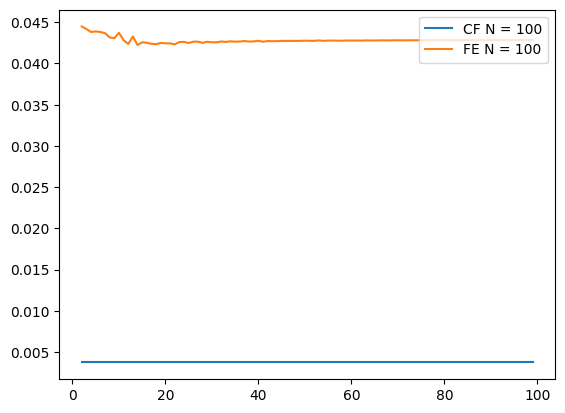

In [104]:
nums = np.arange(2, 100, 1)
errors_cf, errors_fe = [], []
for n_h in nums:
    F = generate_posteriors(N, L, n_h, kappa, s, tau)
    F_cf, F_fe = F[0,:], F[1,:]
    #print("mean of F_fe is {m}".format(m = np.mean(F_fe)))
    errors_cf.append(la.norm(F_cf - f_0)/N)
    errors_fe.append(la.norm(F_fe - f_0)/N)
    #print(n_h, errors_cf[-1], errors_fe[-1])

plot_data = np.array([nums, errors_cf, errors_fe])
plt.plot(plot_data[0], plot_data[1], label = "CF N = 100")
plt.plot(plot_data[0], plot_data[2], label = "FE N = 100")
plt.legend(loc = "upper right")
plt.show()

In [ ]:
# diagnostic test

S_2 = get_FE_design_matrix(data, 2, L)
M_2 = get_mass_matrix(2, L)
G_2 = get_stiffness_matrix(2, L)
Q_2 = get_FE_precision_matrix(M_2, G_2, kappa, s)

for num in np.arange(2, 200, 4):
    S_h = get_FE_design_matrix(data, num, L)
    print("For n_h = {n}, ||S_h|| = {v}".format(n = num, v = la.matrix_norm(S_h)))
    M_h = get_mass_matrix(num, L)
    print("For n_h = {n}, ||M_h|| = {v}".format(n = num, v = la.matrix_norm(M_h)))
    #print("For n_h = {n}, dimension of M_h is {d} and rank is {r}".format(n = num, d = M_h.shape, r = la.matrix_rank(M_h)))
    G_h = get_stiffness_matrix(num, L)
    print("For n_h = {n}, ||G_h|| = {v}".format(n = num, v = la.matrix_norm(G_h)))
    #print("For n_h = {n}, dimension of G_h is {d} and rank is {r}".format(n = num, d = G_h.shape, r = la.matrix_rank(G_h)))
    Q_h = get_FE_precision_matrix(M_h, G_h, kappa, s)
    print("For n_h = {n}, ||Q_h|| = {v}".format(n = num, v = la.matrix_norm(Q_h)))
    #print("For n_h = {n}, dimension of Q_h is {d} and rank is {r}".format(n = num, d = Q_h.shape, r = la.matrix_rank(Q_h)))
    print("")

In [96]:
x = get_ground_truth_vector(data, L, kappa, s, M)

In [98]:
la.vector_norm(x)

np.float64(9.510379317416012)